In [78]:
# %pip install -qU "langchain-google-community[gmail]"
# %pip install -qU langchain-community arxiv
#%pip install -qU langchain-classic langchain-community arxiv #옛 방식 arxiv 패키지

In [79]:
from dotenv import load_dotenv
load_dotenv()

True

In [80]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o")
small_llm = ChatOpenAI(model="gpt-4o-mini")

In [81]:
from langchain_core.tools import tool

@tool
def add(a: int, b: int) -> int:
    """숫자 a와 b를 더합니다."""
    return a + b

@tool
def multiply(a: int, b: int) -> int:
    """숫자 a와 b를 곱합니다."""
    return a * b

In [82]:
from langchain_community.tools import DuckDuckGoSearchRun
search_tool = DuckDuckGoSearchRun()


In [83]:
from langchain_google_community import GmailToolkit
from langchain_google_community.gmail.utils import (
    build_resource_service,
    get_gmail_credentials,
)

# Can review scopes here https://developers.google.com/gmail/api/auth/scopes
# For instance, readonly scope is 'https://www.googleapis.com/auth/gmail.readonly'
credentials = get_gmail_credentials(
    token_file="./google/gmail_token.json",
    scopes=["https://mail.google.com/"],
    client_sercret_file="./google/gmail_credentials.json",
)
api_resource = build_resource_service(credentials=credentials)
gmail_toolkit = GmailToolkit(api_resource=api_resource)
gmail_tool_list = gmail_toolkit.get_tools()

C:\Users\JJH\AppData\Local\Temp\ipykernel_20180\3256258543.py:9: DeprecationWarning: get_gmail_credentials is deprecated and will be removed in a future version.Use get_google_credentials instead.
  credentials = get_gmail_credentials(
C:\Users\JJH\AppData\Local\Temp\ipykernel_20180\3256258543.py:14: DeprecationWarning: build_resource_service is deprecated and will be removed in a future version.Use build_gmail_service instead.
  api_resource = build_resource_service(credentials=credentials)


In [84]:
gmail_tool_list

[GmailCreateDraft(api_resource=<googleapiclient.discovery.Resource object at 0x000002086E047D10>),
 GmailSendMessage(api_resource=<googleapiclient.discovery.Resource object at 0x000002086E047D10>),
 GmailSearch(api_resource=<googleapiclient.discovery.Resource object at 0x000002086E047D10>),
 GmailGetMessage(api_resource=<googleapiclient.discovery.Resource object at 0x000002086E047D10>),
 GmailGetThread(api_resource=<googleapiclient.discovery.Resource object at 0x000002086E047D10>)]

In [85]:
from langchain_classic.agents import load_tools

loaded_tools_list = load_tools(
    ["arxiv"],
)

In [86]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings
from langchain_core.tools.retriever import create_retriever_tool

embedding_function = OpenAIEmbeddings(model='text-embedding-3-large')

vector_store = Chroma(
    embedding_function=embedding_function,
    collection_name = 'real_estate_tax',
    persist_directory='./real_estate_tax_collection'
)
retriever = vector_store.as_retriever(search_kwargs={'k': 3})
retriever_tool = create_retriever_tool(
    retriever=retriever,
    name='real_estate_tax_retriever',
    description='Contains information about real estate tax up to May 2026',
    )

In [87]:
from langgraph.prebuilt import ToolNode

tool_list = [add, multiply,search_tool, retriever_tool] + gmail_tool_list + loaded_tools_list
llm_with_tools = small_llm.bind_tools(tool_list)
tool_node = ToolNode(tool_list)

In [88]:
from langgraph.graph import MessagesState, StateGraph

class AgentState(MessagesState):
    summary: str

graph_builder = StateGraph(AgentState)

In [89]:
from langchain_core.messages import SystemMessage

def agent(state: AgentState) -> AgentState:

    messages = state['messages']
    summary = state['summary']
    
    if summary != '':
        messages = [SystemMessage(content=f'Here is the summary of the earlier conversation: {summary}')] + messages
    
    response = llm_with_tools.invoke(messages)
    
    return {'messages': [response]}

In [90]:
def summarize_messages(state: AgentState) -> AgentState:
    messages = state['messages']
    summary = state['summary']
    
    summary_prompt = f'summarize this chat history below: \n\nchat_history:{messages}'
    
    if summary != '':
        summary_prompt = f'''summarize this chat history below while looking at the summary of earlier conversations
chat_history:{messages}
summary:{summary}'''

    summary = small_llm.invoke(summary_prompt)
    return {'summary': summary.content}

In [91]:
from langchain_core.messages import RemoveMessage

def delete_messages(state: AgentState) -> AgentState:
    
    messages = state['messages']
    delete_messages = [RemoveMessage(id=message.id) for message in messages[:-3]]
    return {'messages': delete_messages}

In [92]:
from typing import Literal

def should_continue(state: AgentState) -> Literal['tools', 'summarize_messages']:

    messages = state['messages']
    last_ai_message = messages[-1]
    
    if last_ai_message.tool_calls:
        return 'tools'
    
    return 'summarize_messages'

In [93]:
graph_builder.add_node('agent', agent)
graph_builder.add_node('tools', tool_node)
graph_builder.add_node(delete_messages)
graph_builder.add_node(summarize_messages)

In [94]:
from langgraph.graph import START, END
from langgraph.prebuilt import tools_condition

graph_builder.add_edge(START, 'agent')
graph_builder.add_conditional_edges(
    'agent',
    # tools_condition
    should_continue,
    ['tools', 'summarize_messages']
)
graph_builder.add_edge('tools', 'agent')
graph_builder.add_edge('summarize_messages', 'delete_messages')
graph_builder.add_edge('delete_messages', END)


In [95]:
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()

graph= graph_builder.compile(
    checkpointer = checkpointer
)

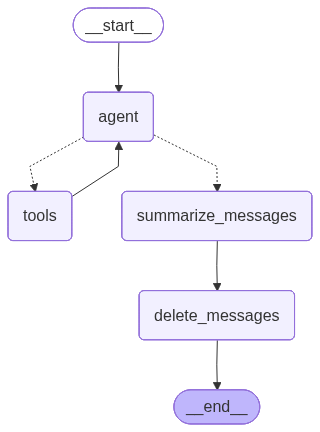

In [96]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [103]:
from langchain_core.messages import HumanMessage

config = {
    'configurable': {
        'thread_id': 'summarize_paper'
    }
}

query = 'spdsd7@naver.com으로 Attention Is All You Need 논문을 요약해서 이메일 초안을 작성해주세요'
for chunk in graph.stream({'messages': [HumanMessage(query)], 'summary': ''}, config=config, stream_mode='values'):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

spdsd7@naver.com으로 Attention Is All You Need 논문을 요약해서 이메일 초안을 작성해주세요
================================== Ai Message ==================================
Tool Calls:
  arxiv (call_8zo0LozcBiyrRZrSqkfa8QkO)
 Call ID: call_8zo0LozcBiyrRZrSqkfa8QkO
  Args:
    query: Attention Is All You Need
================================= Tool Message =================================
Name: arxiv

Published: 2021-05-06
Title: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet
Authors: Luke Melas-Kyriazi
Summary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifically, we replace the attention layer

In [104]:
current_message_list = graph.get_state(config).values['messages']
current_message_list

[AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 207, 'prompt_tokens': 1506, 'total_tokens': 1713, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_11121efef4', 'id': 'chatcmpl-DbiCt4eh8u93YD9KvUcgrAix5IplI', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019df1ee-98d2-74b0-a95d-af9d16bdc5f9-0', tool_calls=[{'name': 'create_gmail_draft', 'args': {'message': '안녕하세요,\n\n저는 "Attention Is All You Need" 논문에 대해 요약을 작성했습니다.\n\n이 논문은 Transformer 아키텍처를 소개하며, 그 구조와 작동 원리를 설명합니다. 주요 혁신은 self-attention 메커니즘으로, 이는 단어 간의 상관 관계를 효율적으로 학습하는 데 기여합니다. 기존의 RNN 및 CNN 모델과 비교할 때, Transformer는 병렬 처리 속도가 빠르고 장기 의존성 문제를 해결합니다. \n\n이 모델은 자연어 처리뿐만 아니라 다양한 분야에

In [105]:
graph.get_state(config).values['summary']


'In this chat, the user requested a draft email summarizing the "Attention Is All You Need" paper and provided their email address. The AI generated a draft, summarizing the paper\'s introduction of the Transformer architecture and its self-attention mechanism, which offers advantages over traditional RNN and CNN models in terms of parallel processing and handling long-term dependencies. The draft emphasized the model\'s effectiveness in various fields and invited further questions. The AI confirmed that the draft was created and asked if the user would like to send it.'

In [99]:
# from langchain_core.messages import RemoveMessage

# for index, message in enumerate(current_message_list):
#     if index < len(current_message_list) - 1:
#         graph.update_state(config, {'messages': RemoveMessage(id=message.id)})

In [106]:
update_query = '논문의 출처 URL을 포함시켜주세요'
for chunk in graph.stream({'messages': [HumanMessage(update_query)]}, config=config, stream_mode='values'):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

논문의 출처 URL을 포함시켜주세요
================================== Ai Message ==================================
Tool Calls:
  create_gmail_draft (call_b9x3br3lqWmKrZgVt56byxcp)
 Call ID: call_b9x3br3lqWmKrZgVt56byxcp
  Args:
    message: 안녕하세요,

저는 "Attention Is All You Need" 논문에 대해 요약을 작성했습니다.

이 논문은 Transformer 아키텍처를 소개하며, 그 구조와 작동 원리를 설명합니다. 주요 혁신은 self-attention 메커니즘으로, 이는 단어 간의 상관 관계를 효율적으로 학습하는 데 기여합니다. 기존의 RNN 및 CNN 모델과 비교할 때, Transformer는 병렬 처리 속도가 빠르고 장기 의존성 문제를 해결합니다. 

이 모델은 자연어 처리뿐만 아니라 다양한 분야에서 좋은 성능을 보이고 있으며, 후속 연구들에서도 널리 사용되고 있습니다.

논문 출처: https://arxiv.org/abs/1706.03762

더 궁금한 점이 있으시면 말씀해 주세요.

감사합니다.
    to: ['spdsd7@naver.com']
    subject: Attention Is All You Need 논문 요약
================================= Tool Message =================================
Name: create_gmail_draft

Draft created. Draft Id: r4244688550578807986
================================== Ai Message ==============================

In [107]:
graph.get_state(config).values['summary']


'In this chat, the user asked the AI to draft an email summarizing the "Attention Is All You Need" paper. The AI provided a draft that explained the Transformer architecture and its innovative self-attention mechanism, highlighting its advantages over traditional RNN and CNN models, including faster parallel processing and better handling of long-term dependencies. The draft also noted the model\'s effectiveness in various fields and invited further questions. After the initial draft was created, the user requested to include the paper\'s source URL, which the AI then successfully incorporated into an updated draft. The AI confirmed the updates and asked if the user would like to send the email.'

In [102]:
# update_query = '초안이 좋습니다. 이메일을 전송해주세요'
# for chunk in graph.stream({'messages': [HumanMessage(update_query)]}, config=config, stream_mode='values'):
#     chunk['messages'][-1].pretty_print()